## LIBRARIES

In [1]:
import os
import json
import time
import random
import logging
import math
import warnings
from datetime import datetime, timedelta
import base64
from io import BytesIO

import numpy as np
import pandas as pd
import joblib
from scipy import stats
from scipy.stats import norm
from scipy.interpolate import griddata
from scipy.spatial import ConvexHull

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.colors import ListedColormap
from IPython.display import display, HTML

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, clone_model, load_model
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, Reshape, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.FATAL)
warnings.filterwarnings('ignore')


## PREPARATION

### Vessel Data Acquisition and Feature Selection


In [ ]:
# MODIFICA QUI: Inserire i percorsi dei file grezzi delle navi, del file porti e della cartella di destinazione "DF"
vessel_files = {
    "ECO ADRIATICA": r"C:\Users\siani\Desktop\ECO ADRIATICA_till.csv",
    "ECO LIVORNO": r"C:\Users\siani\Desktop\ECO LIVORNO_till_.csv"}

# NOTA: si è utilizzato excel con coordinate di tutti i porti
port_file_path = r"C:\Users\siani\Desktop\port_id-Battery 1.csv"
output_folder = r"C:\Users\siani\Desktop\DF"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# INGESTIONE DATI GREZZI E PORTI
df_port = pd.read_csv(port_file_path, sep=',', low_memory=False)
dfs_ships_raw = {}

for vessel_name, file_path in vessel_files.items():
    if os.path.exists(file_path):
        df_raw = pd.read_csv(file_path, sep=',', low_memory=False, encoding='latin1')
        df_raw.columns = df_raw.columns.str.strip()
        df_raw['ts'] = pd.to_datetime(df_raw['ts'], dayfirst=True, format='mixed')
        dfs_ships_raw[vessel_name] = df_raw
    else:
        print(f"Errore: file non trovato per {vessel_name}")

# COSTRUZIONE BOUNDING BOX PORTI
COL_LAT = 'ep_SHIP_LAT_1'  
COL_LON = 'ep_SHIP_LON_1'  

port_bboxes = {}
for _, row in df_port.iterrows():
    port_name = str(row['Port.Name']).strip()
    port_bboxes[port_name] = {
        'lat_min': min(row['Lat1'], row['Lat2']), 'lat_max': max(row['Lat1'], row['Lat2']),
        'lon_min': min(row['Lon1'], row['Lon2']), 'lon_max': max(row['Lon1'], row['Lon2'])}

def identify_port_area_vectorized(df, lat_col, lon_col, bboxes):
    positions = pd.Series("Navigation", index=df.index)
    positions[df[lat_col].isna() | df[lon_col].isna()] = "Unknown"
    for name, bbox in bboxes.items():
        mask = (
            (df[lat_col] >= bbox['lat_min']) & (df[lat_col] <= bbox['lat_max']) &
            (df[lon_col] >= bbox['lon_min']) & (df[lon_col] <= bbox['lon_max'])
        )
        positions[mask] = name
    return positions

# NOTA: Il dataset passato a questa fase di Geofencing è già assunto come pulito.
# In sequenza vengono: 1) Identificati i porti/rotte di navigazione; 2) Assegnati i Voyage ID; 
# 3) Aggregata la telemetria a 15 minuti.
dfs_nav_ships = {}

for vessel_name, df_raw in dfs_ships_raw.items():
    df_raw['Current_Position'] = identify_port_area_vectorized(df_raw, COL_LAT, COL_LON, port_bboxes)

    df_raw['Port_Point'] = df_raw['Current_Position'].replace(["Navigation", "Unknown"], pd.NA)
    df_raw['Departure_Port'] = df_raw['Port_Point'].ffill()
    df_raw['Arrival_Port'] = df_raw['Port_Point'].bfill()
    df_raw['Route'] = df_raw['Departure_Port'].astype(str) + " to " + df_raw['Arrival_Port'].astype(str)

    active_engines = (
        (df_raw['ep_SHA_POW_1'] > 100) | (df_raw['ep_SHA_POW_2'] > 100) | 
        (df_raw['ep_SHA_SPEED_1'] > 10) | (df_raw['ep_SHA_SPEED_2'] > 10))
    vessel_moving = (df_raw['ep_SHIP_SOG_1'] > 4) | active_engines

    df_nav_filtered = df_raw[
        (df_raw['Current_Position'] == "Navigation") & 
        vessel_moving &
        (df_raw['Departure_Port'].notna()) & 
        (df_raw['Departure_Port'] != df_raw['Arrival_Port'])].copy()

    if df_nav_filtered.empty:
        continue

    df_nav_filtered = df_nav_filtered.sort_values('ts').reset_index(drop=True)
    df_nav_filtered['Voyage_ID'] = (df_nav_filtered['ts'].diff() > pd.Timedelta(minutes=30)).cumsum()
    
    df_nav = df_nav_filtered[df_nav_filtered['Route'] != "nan to nan"].reset_index(drop=True)
    dfs_nav_ships[vessel_name] = df_nav

# AGGREGAZIONE A 15 MINUTI E SALVATAGGIO IN CARTELLA "DF"
for vessel_name, df_vessel_orig in dfs_nav_ships.items():
    df_vessel = df_vessel_orig.copy().reset_index(drop=True)
    df_vessel['ts'] = pd.to_datetime(df_vessel['ts'])

    sha_cols = [c for c in ['ep_SHA_POW_1', 'ep_SHA_POW_2'] if c in df_vessel.columns]
    shg_cols = [c for c in ['ep_SHG_POW_1', 'ep_SHG_POW_2'] if c in df_vessel.columns]
    
    if sha_cols:
        df_vessel['SHA_POW_TOT'] = df_vessel[sha_cols].sum(axis=1)
    if shg_cols:
        df_vessel['SHG_POW_TOT'] = df_vessel[shg_cols].sum(axis=1)

    agg_rules = {}
    for col in df_vessel.columns:
        if col in ['Voyage_ID', 'ts']: 
            continue
        elif col in ['Route', 'Current_Position', 'Departure_Port', 'Arrival_Port', 'Cluster_Number']:
            agg_rules[col] = 'first'
        elif 'State' in col or 'Cluster' in col:
            agg_rules[col] = lambda x: x.mode()[0] if not x.mode().empty else np.nan
        else:
            agg_rules[col] = 'median'

    df_agg = (
        df_vessel
        .set_index('ts')
        .groupby('Voyage_ID')
        .resample('15min') 
        .agg(agg_rules))
   
    df_agg = df_agg.dropna(subset=['Route']).reset_index()
    df_final = df_agg.sort_values(by=['Voyage_ID', 'ts']).reset_index(drop=True)
    df_final['miglia'] = df_final['ep_SHIP_SOG_1'] / 4.0

    safe_name = vessel_name.replace(" ", "_")
    file_path = os.path.join(output_folder, f"refined_15min_{safe_name}.csv")
    df_final.to_csv(file_path, index=False)
    print(f"Salvato con successo: {file_path}")


In [2]:
# MODIFICA QUI: Inserire il percorso della cartella dati e i nomi delle navi con cui sono salvati i file
input_path = r"C:\Users\siani\Desktop\[documenti]\[università]\DF" 
vessel_names = ["ECO ADRIATICA", "ECO LIVORNO"]

datasets = {}

def clean_flow_dropouts_interpolation(df, col):
    y = df[col].values.copy()
    df_temp = pd.Series(y)
    df_temp[y < 0.3] = np.nan
    return df_temp.interpolate(method='linear').ffill().bfill().values

dir_columns_to_transform = ['ep_SHIP_SEADIR_1', 'ep_WH_SWELLD_1', 'ep_WH_WAVED_1', 'ep_WH_DIR_1']

for name in vessel_names:
    safe_name = name.replace(" ", "_")
    file_path = os.path.join(input_path, f"refined_15min_{safe_name}.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=',')
        df['ts'] = pd.to_datetime(df['ts'])
        df = df.sort_values('ts')
        
        df['ep_ME_FLW_SUP_1'] = clean_flow_dropouts_interpolation(df, 'ep_ME_FLW_SUP_1')
        df['ep_ME_FLW_SUP_2'] = clean_flow_dropouts_interpolation(df, 'ep_ME_FLW_SUP_2')
        
        for col in dir_columns_to_transform:
            if col in df.columns:
                rad = np.deg2rad(df[col])
                df[f'{col}_SIN'] = np.sin(rad)
                df[f'{col}_COS'] = np.cos(rad)
                df.drop(columns=[col], inplace=True)
                
        datasets[name] = df
    else:
        print(f"Errore: file non trovato per {name}")

navigation_vars = ['ep_SHIP_SOG_1', 'ep_SHIP_STW_1', 'ep_SHIP_DRAFTAFT_1', 'ep_SHIP_DRAFTFOR_1', 'ep_SHIP_HEAD_1', 'miglia']
power_vars = ['SHA_POW_TOT', 'SHG_POW_TOT']
weather_vars = [
   'ep_SHIP_STEMP_1', 'ep_WH_AIRT_1', 
    'ep_WH_SWELLH_1', 'ep_WH_SWELLP_1', 
    'ep_WH_WAVEH_1', 'ep_WH_WAVEP_1', 
    'ep_WH_SPEED_1']

position_vars = ['ep_SHIP_LAT_1', 'ep_SHIP_LON_1']
target_vars = ['ep_ME_FLW_SUP_1', 'ep_ME_FLW_SUP_2']

required_features = navigation_vars + power_vars + weather_vars + target_vars + position_vars


## LSTM TENSOR PREPARATION

In [ ]:
# MODIFICA QUI: Parametri di configurazione delle sequenze temporali LSTM
# - lookback = 16 corrisponde a 4 ore di memoria storica (16 campioni a intervalli di 15 min).
# - min_trip_rows = 17. 
# NOTA: Se si modifica 'lookback', aggiornare proporzionalmente 'min_trip_rows' (deve essere >= lookback + horizon 
# per assicurare che la rete esegua almeno 1 step di previsione).
lookback = 16          
horizon = 1           
min_trip_rows = 17    
target_features = ['ep_ME_FLW_SUP_1', 'ep_ME_FLW_SUP_2']

lstm_data = {}
vessel_scalers = {}
global_route_stats = []

def create_sequences_by_trip(df, features, targets, lb, hr):
    xs, ys, ts_list = [], [], []
    for _, df_trip in df.groupby('Voyage_ID'):
        if len(df_trip) >= lb + hr:
            x_vals = df_trip[features].values
            y_vals = df_trip[targets].values
            ts_vals = pd.to_datetime(df_trip['ts']).values
            
            for i in range(len(x_vals) - lb - hr + 1):
                time_diff = (ts_vals[i + lb + hr - 1] - ts_vals[i]) / np.timedelta64(1, 'm')
                expected_diff = (lb + hr - 1) * 15
                
                if time_diff == expected_diff:
                    xs.append(x_vals[i : i + lb])
                    target_seq = y_vals[i + lb : i + lb + hr]
                    ys.append(target_seq.flatten() if hr == 1 else target_seq)
                    ts_list.append(ts_vals[i + lb])
                    
    return np.array(xs), np.array(ys), np.array(ts_list)

for name, df_raw in datasets.items():
    df = df_raw.copy().sort_values('ts')
    
    if 'input_vectors' in globals() and name in input_vectors:
        input_cols = [f for f in input_vectors[name] if f in df.columns and f not in target_features]
    else:
        input_cols = [f for f in required_features if f in df.columns and f not in target_features and f not in ['Route', 'Cluster_Number']]
    
    trip_counts = df.groupby('Voyage_ID').size()
    valid_trip_ids = trip_counts[trip_counts >= min_trip_rows].index.tolist()
   
    train_ids, val_ids, test_ids = [], [], []
    
    if 'Route' not in df.columns:
        df['Route'] = "Unknown Route"
            
    unique_routes = df['Route'].dropna().unique()

    for route in unique_routes:
        route_voyages = df[(df['Route'] == route) & (df['Voyage_ID'].isin(valid_trip_ids))]['Voyage_ID'].unique()
        n_trips = len(route_voyages)
        
        if n_trips == 0: 
            continue
        elif n_trips < 3: 
            train_ids.extend(route_voyages)
            continue

        # Split stratificato per rotta: TRAIN 70% - VAL 15% - TEST 15%
        # MODIFICABILE anche in 80% 10% 10% OPPURE 70% 20% 10%
        train_split = int(n_trips * 0.7)
        val_split = int(n_trips * 0.85)
        
        if train_split == 0: train_split = 1
        if val_split <= train_split: val_split = train_split + 1
        if val_split >= n_trips: 
            val_split = n_trips - 1
            if train_split >= val_split:
                train_split = val_split - 1
        
        train_ids.extend(route_voyages[:train_split])
        val_ids.extend(route_voyages[train_split:val_split])
        test_ids.extend(route_voyages[val_split:])
    
    train_df = df[df['Voyage_ID'].isin(train_ids)].copy()
    val_df = df[df['Voyage_ID'].isin(val_ids)].copy()
    test_df = df[df['Voyage_ID'].isin(test_ids)].copy()

    # Normalizzazione con MinMaxScaler (Fit eseguito ESCLUSIVAMENTE sul Train set)
    sc_x, sc_y = MinMaxScaler(), MinMaxScaler()
    
    if not train_df.empty:
        train_df[input_cols] = sc_x.fit_transform(train_df[input_cols])
        train_df[target_features] = sc_y.fit_transform(train_df[target_features])

    for d_set in [val_df, test_df]:
        if not d_set.empty:
            d_set[input_cols] = sc_x.transform(d_set[input_cols])
            d_set[target_features] = sc_y.transform(d_set[target_features])

    vessel_scalers[name] = {'scaler_x': sc_x, 'scaler_y': sc_y}

    # SALVATAGGIO SCALER SU DISCO (Fondamentale per l'inferenza futura)
    safe_name = name.replace(" ", "_")
    joblib.dump(sc_x, f"scaler_x_{safe_name}.pkl")
    joblib.dump(sc_y, f"scaler_y_{safe_name}.pkl")

    x_train, y_train, ts_train = create_sequences_by_trip(train_df, input_cols, target_features, lookback, horizon) if not train_df.empty else (np.array([]), np.array([]), np.array([]))
    x_val, y_val, ts_val = create_sequences_by_trip(val_df, input_cols, target_features, lookback, horizon) if not val_df.empty else (np.array([]), np.array([]), np.array([]))
    x_test, y_test, ts_test = create_sequences_by_trip(test_df, input_cols, target_features, lookback, horizon) if not test_df.empty else (np.array([]), np.array([]), np.array([]))

    lstm_data[name] = {
        'x_train': x_train, 'y_train': y_train,
        'x_val': x_val, 'y_val': y_val,
        'x_test': x_test, 'y_test': y_test,
        'features_name': input_cols,
        'ts_test': ts_test
    }

    for route in unique_routes:
        route_v = df[df['Route'] == route]['Voyage_ID'].unique()
        tr = len([v for v in route_v if v in train_ids])
        vl = len([v for v in route_v if v in val_ids])
        ts = len([v for v in route_v if v in test_ids])
        
        if (tr + vl + ts) > 0:
            global_route_stats.append({'Route': route, 'Vessel': name, 'Train': tr, 'Val': vl, 'Test': ts})

if global_route_stats:
    df_global = pd.DataFrame(global_route_stats)
    vessels = sorted(df_global['Vessel'].unique())
    unique_routes_all = df_global['Route'].unique()
    
    pivot_data = []
    for route in unique_routes_all:
        row_dict = {'Route': route}
        for v in vessels:
            subset = df_global[(df_global['Route'] == route) & (df_global['Vessel'] == v)]
            if not subset.empty:
                row_dict[f"{v} (Tr)"] = int(subset['Train'].iloc[0])
                row_dict[f"{v} (Val)"] = int(subset['Val'].iloc[0])
                row_dict[f"{v} (Ts)"] = int(subset['Test'].iloc[0])
            else:
                row_dict[f"{v} (Tr)"] = 0
                row_dict[f"{v} (Val)"] = 0
                row_dict[f"{v} (Ts)"] = 0
        pivot_data.append(row_dict)
        
    df_pivot = pd.DataFrame(pivot_data)
    df_pivot['Total_Vol'] = df_pivot.drop(columns=['Route']).sum(axis=1)
    df_pivot = df_pivot.sort_values('Total_Vol', ascending=False).drop(columns=['Total_Vol'])
    
    print("\n--- RIPARTIZIONE GLOBALE ROTTE PER NAVI ---")
    print(df_pivot.to_string(index=False))



--- RIPARTIZIONE GLOBALE ROTTE PER NAVI ---
                            Route  ECO ADRIATICA (Tr)  ECO ADRIATICA (Val)  ECO ADRIATICA (Ts)  ECO LIVORNO (Tr)  ECO LIVORNO (Val)  ECO LIVORNO (Ts)
            BARCELONA to VALENCIA                  21                    4                   5                41                  9                 9
              SAVONA to BARCELONA                  23                    5                   6                38                  8                 9
            VALENCIA to BARCELONA                  18                    4                   5                40                  9                 9
                SAVONA to LIVORNO                  20                    4                   5                35                  8                 8
                LIVORNO to SAVONA                  21                    4                   5                34                  7                 8
              BARCELONA to SAVONA                  16  

## HYPERPARAMETER OPTIMIZATION: IMPROVED GREY WOLF OPTIMIZER

In [ ]:
def fitness_function(params, x_train_opt, y_train_opt):
    u, lr, bs, dr = int(params[0]), params[1], int(params[2]), params[3]
    n_steps, n_feat = x_train_opt.shape[1], x_train_opt.shape[2]
    n_out = y_train_opt.shape[1]
    start_time = time.time()
    
    model = Sequential([
        Input(shape=(n_steps, n_feat)),
        LSTM(u, return_sequences=True),
        Dropout(dr),
        LSTM(int(u/2)),
        Dropout(dr),
        Dense(16, activation='relu'),
        Dense(n_out, activation='linear')])
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    
    hist = model.fit(
        x_train_opt, y_train_opt, 
        validation_split=0.2, 
        epochs=10, 
        batch_size=bs, 
        callbacks=[stop], 
        verbose=0)
    
    val_loss = min(hist.history['val_loss'])
    comp_efficiency = (time.time() - start_time) / 100 
    mem_usage = model.count_params() / 1000000 
    
    total_fitness = val_loss + (0.1 * comp_efficiency) + (0.1 * mem_usage)
    K.clear_session() 
    return total_fitness

class IGWO:
    def __init__(self, n_wolves=10, max_iter=10, patience=5):
        self.n_wolves, self.max_iter, self.patience = n_wolves, max_iter, patience
        self.lb = np.array([64, 0.0005, 16, 0.1])
        self.ub = np.array([256, 0.005, 64, 0.4])
    
    def run(self, x_tr, y_tr):
        pos = np.random.uniform(self.lb, self.ub, (self.n_wolves, 4))
        alpha_pos, alpha_score = np.zeros(4), float("inf")
        beta_pos, beta_score = np.zeros(4), float("inf")
        delta_pos, delta_score = np.zeros(4), float("inf")
        stagnant_count = 0

        for t in range(self.max_iter):
            old_best_score = alpha_score
            for i in range(self.n_wolves):
                pos[i] = np.clip(pos[i], self.lb, self.ub)
                fit = fitness_function(pos[i], x_tr, y_tr)
                
                if fit < alpha_score: alpha_score, alpha_pos = fit, pos[i].copy()
                elif fit < beta_score: beta_score, beta_pos = fit, pos[i].copy()
                elif fit < delta_score: delta_score, delta_pos = fit, pos[i].copy()
            
            print(f"Iterazione IGWO {t+1}/{self.max_iter} - Best Fitness: {alpha_score:.6f}", flush=True)
            
            if t > 0:
                if (old_best_score - alpha_score) < 1e-6: stagnant_count += 1
                else: stagnant_count = 0
                if stagnant_count >= self.patience:
                    print(f"Early stopping: convergenza raggiunta all'iterazione {t+1}", flush=True)
                    break

            a_val = 2 * (1 - (t**2 / self.max_iter**2))
            eps = 1e-10
            
            w1, w2, w3 = 1.0/(alpha_score+eps), 1.0/(beta_score+eps), 1.0/(delta_score+eps)
            w_sum = w1 + w2 + w3
            
            for i in range(self.n_wolves):
                for j in range(4):
                    r1, r2 = np.random.random(), np.random.random()
                    x1 = alpha_pos[j] - (2*a_val*r1 - a_val) * abs(2*r2 * alpha_pos[j] - pos[i, j])
                    r1, r2 = np.random.random(), np.random.random()
                    x2 = beta_pos[j] - (2*a_val*r1 - a_val) * abs(2*r2 * beta_pos[j] - pos[i, j])
                    r1, r2 = np.random.random(), np.random.random()
                    x3 = delta_pos[j] - (2*a_val*r1 - a_val) * abs(2*r2 * delta_pos[j] - pos[i, j])
                    pos[i, j] = (w1 * x1 + w2 * x2 + w3 * x3) / w_sum
                    
        return alpha_pos


# MODIFICA QUI: Selezionare la nave target su cui eseguire l'ottimizzazione IGWO
TARGET_VESSEL = "ECO ADRIATICA"
max_iter_igwo = 10    
n_wolves = 10    
sampling_ratio = 1.0 

# MODIFICA QUI: Cartella di destinazione salvataggio parametri (Cartella DF)
output_dir = r"C:\Users\siani\Desktop\DF"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

name = TARGET_VESSEL
safe_name = name.replace(' ', '_')
output_path = os.path.join(output_dir, f"opt_params_{safe_name}.json")

# NOTA METODOLOGICA: L'ottimizzazione IGWO viene eseguita ESCLUSIVAMENTE 
# sui viaggi del set di Training per prevenire qualsiasi fenomeno di Data Leakage sui set di Validation e Test.
all_trips = datasets[name]['Voyage_ID'].unique()
train_split_idx = int(len(all_trips) * 0.7)
train_ids = all_trips[:train_split_idx]
    
n_sample = int(len(train_ids) * sampling_ratio)
sample_trips = train_ids[:n_sample]
    
df_opt = datasets[name][datasets[name]['Voyage_ID'].isin(sample_trips)].copy()
sc_x, sc_y = vessel_scalers[name]['scaler_x'], vessel_scalers[name]['scaler_y']
feats = lstm_data[name]['features_name']
    
df_opt[feats] = sc_x.transform(df_opt[feats])
df_opt[target_features] = sc_y.transform(df_opt[target_features])

x_opt, y_opt, _ = create_sequences_by_trip(df_opt, feats, target_features, lookback, horizon)
x_opt, y_opt = x_opt.astype('float32'), y_opt.astype('float32')
    
if len(x_opt) == 0:
    print("Esecuzione annullata: tensore delle sequenze vuoto.")
else:
    optimizer = IGWO(n_wolves=n_wolves, max_iter=max_iter_igwo)
    best_params = optimizer.run(x_opt, y_opt)
        
    final_params = {
        "vessel_name": name, 
        "lstm_units": int(best_params[0]),
        "learning_rate": float(best_params[1]), 
        "batch_size": int(best_params[2]),
        "dropout_rate": float(best_params[3]), 
        "lookback": lookback, 
        "features_count": len(feats)
    }
        
    with open(output_path, 'w') as f:
        json.dump(final_params, f, indent=4)
        
    print(f"\nOttimizzazione completata per {name}!")
    print(f"Parametri salvati in: {output_path}")
    print(f"Risultati: Units={final_params['lstm_units']}, LR={final_params['learning_rate']:.5f}, BatchSize={final_params['batch_size']}, Dropout={final_params['dropout_rate']:.2f}")


## LAYER LSTM

Scaler X e Scaler Y salvati con successo in: C:\Users\siani\Desktop\DF
Parametri IGWO caricati: Units=64, LR=0.00500, Batch=53, Dropout=0.18

Avvio addestramento LSTM per ECO ADRIATICA...
Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0121 - mae: 0.1109 - val_loss: 0.0067 - val_mae: 0.0946
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0049 - mae: 0.0740 - val_loss: 0.0062 - val_mae: 0.0855
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0034 - mae: 0.0585 - val_loss: 0.0061 - val_mae: 0.0898
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0028 - mae: 0.0531 - val_loss: 0.0062 - val_mae: 0.0823
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - mae: 0.0497 - val_loss: 0.0051 - val_mae: 0.0789
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0023 - mae: 0.0461 - val_loss: 0.0043 - val_mae: 0.0702
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0022 - mae: 0.0455 - val_los

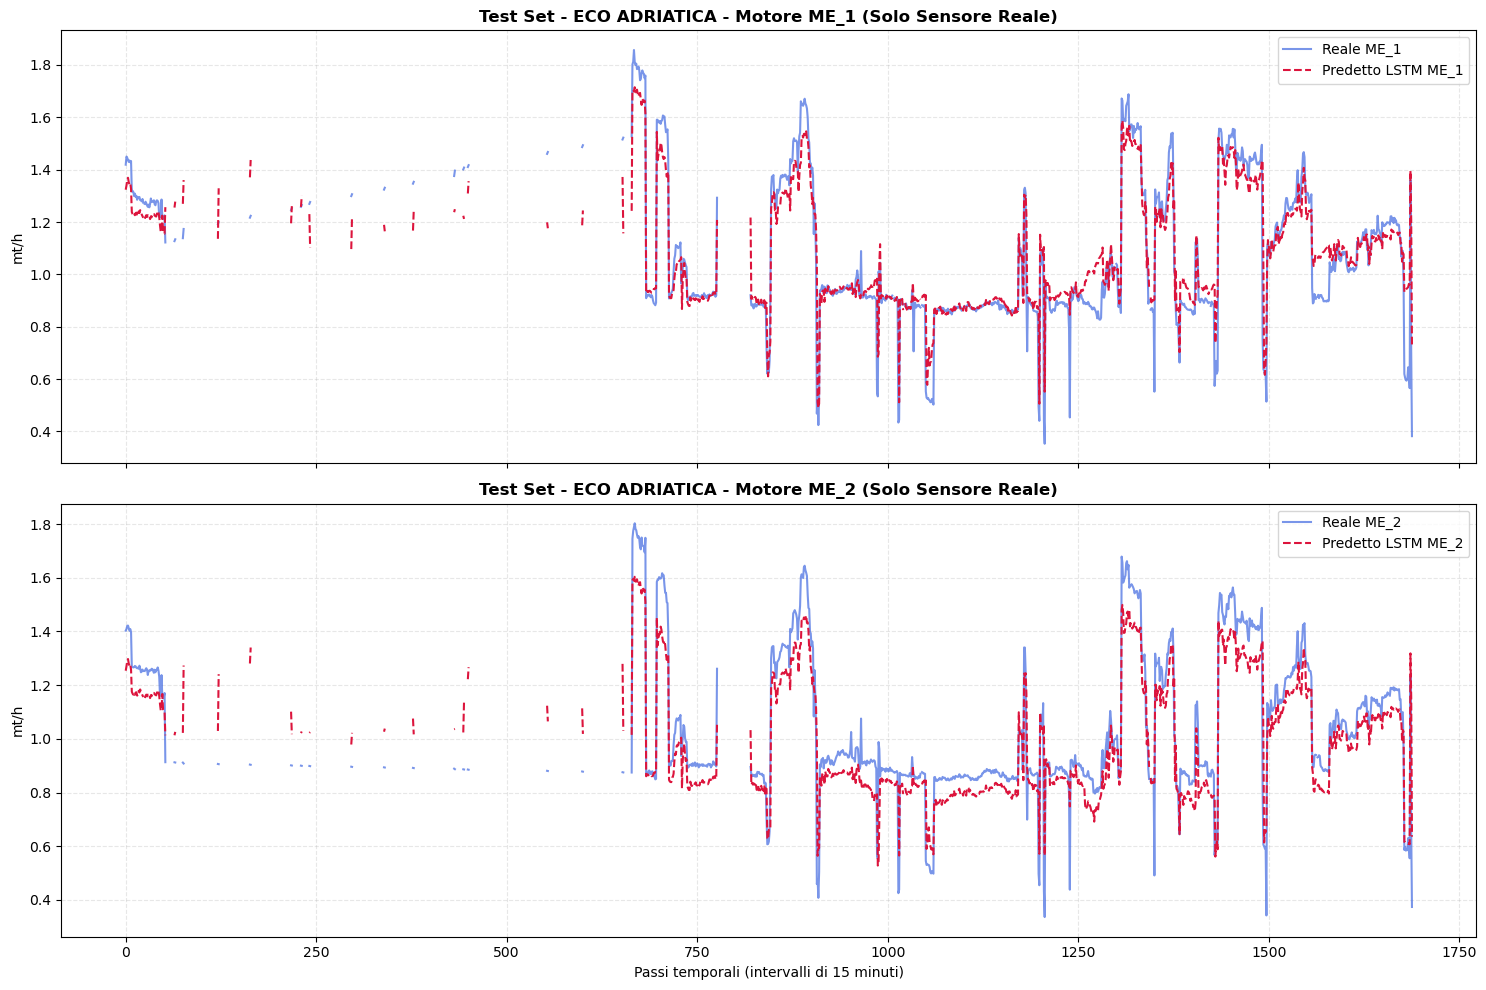

In [4]:
# ==============================================================================
# SEZIONE ADDESTRAMENTO MODELLO LSTM E VALUTAZIONE SUL TEST SET (SENSORE REALE)
# ==============================================================================

# MODIFICA QUI: Selezionare la nave target per l'addestramento e la valutazione
TARGET_VESSEL = "ECO ADRIATICA"

# MODIFICA QUI: Cartella di destinazione salvataggio (Cartella DF)
output_dir = r"C:\Users\siani\Desktop\DF"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

if 'results_storage_igwo' not in globals():
    results_storage_igwo = {}

name = TARGET_VESSEL
safe_name = name.replace(' ', '_')

if name not in lstm_data: 
    print(f"Attenzione: {name} non è presente in lstm_data. Impossibile procedere.")
else:
    d = lstm_data[name]
    x_tr, y_tr = d['x_train'], d['y_train']
    x_vl, y_vl = d['x_val'], d['y_val']
    x_ts, y_ts = d['x_test'], d['y_test']
    
    # Recupero Scaler X e Scaler Y da vessel_scalers
    if 'vessel_scalers' in globals() and name in vessel_scalers:
        scaler_x = vessel_scalers[name]['scaler_x']
        scaler_y = vessel_scalers[name]['scaler_y']
    else:
        scaler_x_path = os.path.join(output_dir, f"scaler_x_{safe_name}.pkl")
        scaler_y_path = os.path.join(output_dir, f"scaler_y_{safe_name}.pkl")
        scaler_x = joblib.load(scaler_x_path)
        scaler_y = joblib.load(scaler_y_path)
    
    n_outputs = y_tr.shape[1] 
    
    # Salvataggio immediato e sincronizzato degli Scaler su disco nella cartella DF
    scaler_x_path = os.path.join(output_dir, f"scaler_x_{safe_name}.pkl")
    scaler_y_path = os.path.join(output_dir, f"scaler_y_{safe_name}.pkl")
    joblib.dump(scaler_x, scaler_x_path)
    joblib.dump(scaler_y, scaler_y_path)
    print(f"Scaler X e Scaler Y salvati con successo in: {output_dir}")

    # Caricamento parametri ottimali IGWO
    param_file = os.path.join(output_dir, f"opt_params_{safe_name}.json")
    if not os.path.exists(param_file):
        param_file = f"opt_params_{safe_name}.json"
        
    if os.path.exists(param_file):
        with open(param_file, "r") as f:
            p = json.load(f)
        u, lr, bs, dr = p["lstm_units"], p["learning_rate"], p["batch_size"], p["dropout_rate"]
        print(f"Parametri IGWO caricati: Units={u}, LR={lr:.5f}, Batch={bs}, Dropout={dr:.2f}")
    else:
        u, lr, bs, dr = 64, 0.001, 32, 0.2

    # Definizione Architettura Rete LSTM
    model = Sequential([
        Input(shape=(x_tr.shape[1], x_tr.shape[2])),
        LSTM(u, return_sequences=True, activation='tanh'),
        Dropout(dr),
        LSTM(int(u/2), activation='tanh'),
        Dropout(dr),
        Dense(16, activation='relu'),
        Dense(n_outputs, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='huber', metrics=['mae'])
    stop = EarlyStopping(monitor='val_loss', patience=55, restore_best_weights=True)

    print(f"\nAvvio addestramento LSTM per {name}...")
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_vl, y_vl),
        epochs=100,
        batch_size=bs,
        callbacks=[stop],
        verbose=1
    )

    pred_scaled = model.predict(x_ts)
    pred_real = scaler_y.inverse_transform(pred_scaled)
    real_real = scaler_y.inverse_transform(y_ts)

    # CORREZIONE METODOLOGICA: Riconoscimento dei segmenti con sensore reale attivo
    is_real_sensor = np.ones(len(real_real), dtype=bool)
    if len(real_real) > 2:
        diff2 = np.abs(np.diff(real_real[:, 0], n=2))
        interpolated_mask = np.pad(diff2 < 1e-6, (1, 1), mode='edge')
        is_real_sensor = ~interpolated_mask

    results_storage_igwo[name] = {
        'real': real_real, 
        'pred': pred_real,
        'is_real_sensor': is_real_sensor,
        'history': history.history
    }
    
    model_save_path = os.path.join(output_dir, f"model_{safe_name}_igwo.keras")
    model.save(model_save_path)
    print(f"Modello salvato con successo in: {model_save_path}")

# ==============================================================================
# METRICHE DI TEST (CALCOLATE ESCLUSIVAMENTE SUL SENSORE REALE FUNZIONANTE)
# ==============================================================================

performance_report = []
if name in results_storage_igwo:
    real = results_storage_igwo[name]['real']
    pred = results_storage_igwo[name]['pred']
    mask_sensor = results_storage_igwo[name]['is_real_sensor']
    
    for i, target_col in enumerate(target_vars):
        if i >= real.shape[1]: 
            break
        
        valid_mask = mask_sensor & (real[:, i] > 0.3)
        r_vals = real[valid_mask, i]
        p_vals = pred[valid_mask, i]
        
        mae = mean_absolute_error(r_vals, p_vals)
        mse = mean_squared_error(r_vals, p_vals)
        r2 = r2_score(r_vals, p_vals)
        mape = np.mean(np.abs((r_vals - p_vals) / r_vals)) * 100
        
        performance_report.append({
            'vessel': name,
            'engine': target_col.replace('ep_', '').replace('_FLW_SUP', ''),
            'mae (mt/h)': round(mae, 3),
            'mse (mt/h)^2': round(mse, 6),
            'r2 score': round(r2, 4),
            'mape (%)': round(mape, 2)
        })

if performance_report:
    print("\n" + "="*85)
    print(f"REPORT METRICHE TEST SET (ESCLUSIVAMENTE SENSORE REALE ATTIVO) - {name}")
    print("="*85)
    df_perf = pd.DataFrame(performance_report)
    print(df_perf.to_string(index=False))
    print("="*85)
    
    csv_filename = os.path.join(output_dir, f"performance_testset_{safe_name}_igwo.csv")
    df_perf.to_csv(csv_filename, index=False)

# ==============================================================================
# GRAFICO TEMPORALE (SOLO SENSORE REALE ATTIVO)
# ==============================================================================

if name in results_storage_igwo:
    real = results_storage_igwo[name]['real'].copy()
    pred = results_storage_igwo[name]['pred'].copy()
    mask_sensor = results_storage_igwo[name]['is_real_sensor']
    
    real[~mask_sensor] = np.nan
    pred[~mask_sensor] = np.nan
    
    n_engines = real.shape[1]
    fig, axes = plt.subplots(n_engines, 1, figsize=(15, 5 * n_engines), sharex=True)
    
    if n_engines == 1: 
        axes = [axes]
    
    for i in range(n_engines):
        engine_label = target_vars[i].replace('ep_', '').replace('_FLW_SUP', '')
        
        axes[i].plot(real[:, i], color='royalblue', label=f'Reale {engine_label}', alpha=0.7)
        axes[i].plot(pred[:, i], color='crimson', label=f'Predetto LSTM {engine_label}', linestyle='--', lw=1.5)
        
        axes[i].set_title(f"Test Set - {name} - Motore {engine_label} (Solo Sensore Reale)", fontweight='bold')
        axes[i].set_ylabel("mt/h")
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle='--', alpha=0.3)
    
    axes[-1].set_xlabel("Passi temporali (intervalli di 15 minuti)")
    plt.tight_layout()
    
    plot_filename = os.path.join(output_dir, f"test_plot_{safe_name}_igwo.png")
    plt.savefig(plot_filename, dpi=300)
    plt.show()


## SCALA BEAUFORT DEFINITION

In [65]:
# MODIFICA QUI: Selezionare la nave di riferimento per la profilazione della scala Beaufort
TARGET_VESSEL = "ECO ADRIATICA"

# MODIFICA QUI: Cartella di destinazione salvataggio (Cartella DF)
output_dir = r"C:\Users\siani\Desktop\DF"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df_historical = datasets[TARGET_VESSEL].copy()

available_features = [f for f in weather_vars if f in df_historical.columns]
df_clean = df_historical.dropna(subset=available_features).copy()

# MODIFICA QUI: Suddivisione in 13 quantili (0-12) basati ESCLUSIVAMENTE sul vento e conversione immediata in intero
df_clean['Beaufort_Level'] = pd.qcut(df_clean['ep_WH_SPEED_1'], q=13, labels=False, duplicates='drop').astype(int)

df_centroids = df_clean.groupby('Beaufort_Level', observed=False)[available_features].median()
df_centroids = df_centroids.reindex(range(13)).interpolate(method='linear').ffill().bfill()

global_beaufort_consumption_scale = df_centroids.to_dict(orient='index')

scale_path = os.path.join(output_dir, "global_beaufort_consumption_scale.pkl")
joblib.dump(global_beaufort_consumption_scale, scale_path)

df_scale = df_centroids.copy()
df_scale.index.name = 'Beaufort-Style Level'
df_scale.reset_index(inplace=True)

# MODIFICA QUI: Vengono visualizzate a schermo tutte le variabili meteo calcolate
cols_to_show = ['Beaufort-Style Level'] + available_features
cols_present = [c for c in cols_to_show if c in df_scale.columns]

styled_scale = df_scale[cols_present].style.background_gradient(
    subset=['ep_WH_SPEED_1'], 
    cmap='YlOrRd'
).format(precision=2)

display(styled_scale)


df_historical_labeled = df_clean.copy()
output_path = os.path.join(output_dir, "df_historical_beaufort_labeled.pkl")
joblib.dump(df_historical_labeled, output_path)
print(f"Dataset storico etichettato Beaufort salvato con successo in: {output_path}")

,Beaufort-Style Level,ep_SHIP_STEMP_1,ep_WH_AIRT_1,ep_WH_SWELLH_1,ep_WH_SWELLP_1,ep_WH_WAVEH_1,ep_WH_WAVEP_1,ep_WH_SPEED_1
0,0,14.40,15.90,0.62,4.70,0.87,4.40,0.03
1,1,14.40,16.30,0.59,4.70,0.85,4.30,0.06
2,2,14.43,16.30,0.59,4.80,0.85,4.40,0.08
3,3,14.68,16.60,0.60,4.70,0.87,4.30,0.10
4,4,14.50,17.00,0.62,4.80,0.89,4.30,0.12
5,5,15.50,18.00,0.61,4.80,0.87,4.40,0.14
6,6,15.00,17.10,0.64,4.70,0.94,4.30,0.16
7,7,16.18,18.20,0.62,4.70,0.93,4.30,0.19
8,8,15.70,18.60,0.66,4.80,1.00,4.40,0.21
9,9,15.28,18.70,0.74,4.90,1.04,4.50,0.24


Dataset storico etichettato Beaufort salvato con successo in: C:\Users\siani\Desktop\DF\df_historical_beaufort_labeled.pkl


## SCHEDULE FUTURE VOYAGE


In [ ]:
# MODIFICA QUI: Inserire i dati della pianificazione
schedule_data = [
    {
        "departure_port": "Valencia", "arrival_port": "Barcelona",
        "route": "VALENCIA to BARCELONA", "route_key": "VALENCIA_BARCELONA",
        "distance_nm": 158.46, "time_at_sea_h": 11.7,
        "draft_aft": 6.6, "draft_fore": 6.3,
        "avg_speed": 16.01, "real_fuel_mt": 18.2,
        "beaufort_level": 3, "departure_month": 2
    },
    {
        "departure_port": "Barcelona", "arrival_port": "Livorno",
        "route": "BARCELONA to LIVORNO", "route_key": "BARCELONA_LIVORNO",
        "distance_nm": 388.23, "time_at_sea_h": 21.1,
        "draft_aft": 7.0, "draft_fore": 6.7,
        "avg_speed": 20.45, "real_fuel_mt": 64.5,
        "beaufort_level": 4, "departure_month": 2
    },
    {
        "departure_port": "Livorno", "arrival_port": "Savona",
        "route": "LIVORNO to SAVONA", "route_key": "LIVORNO_SAVONA",
        "distance_nm": 89.36, "time_at_sea_h": 6.4,
        "draft_aft": 6.7, "draft_fore": 6.4,
        "avg_speed": 20.38, "real_fuel_mt": 14.6,
        "beaufort_level": 3, "departure_month": 2
    },
    {
        "departure_port": "Savona", "arrival_port": "Barcelona",
        "route": "SAVONA to BARCELONA", "route_key": "SAVONA_BARCELONA",
        "distance_nm": 344.53, "time_at_sea_h": 19.3,
        "draft_aft": 6.7, "draft_fore": 6.5,
        "avg_speed": 20.28, "real_fuel_mt": 51.7,
        "beaufort_level": 4, "departure_month": 2
    },
    {
        "departure_port": "Barcelona", "arrival_port": "Valencia",
        "route": "BARCELONA to VALENCIA", "route_key": "BARCELONA_VALENCIA",
        "distance_nm": 157.37, "time_at_sea_h": 12.8,
        "draft_aft": 6.5, "draft_fore": 6.3,
        "avg_speed": 14.74, "real_fuel_mt": 17.6,
        "beaufort_level": 3, "departure_month": 2
    },
    {
        "departure_port": "Valencia", "arrival_port": "Savona",
        "route": "VALENCIA to SAVONA", "route_key": "VALENCIA_SAVONA",
        "distance_nm": 506.65, "time_at_sea_h": 33.5,
        "draft_aft": 6.9, "draft_fore": 6.6,
        "avg_speed": 15.74, "real_fuel_mt": 61.2,
        "beaufort_level": 4, "departure_month": 2
    },
    {
        "departure_port": "Savona", "arrival_port": "Livorno",
        "route": "SAVONA to LIVORNO", "route_key": "SAVONA_LIVORNO",
        "distance_nm": 84.35, "time_at_sea_h": 8.0,
        "draft_aft": 6.1, "draft_fore": 6.0,
        "avg_speed": 14.85, "real_fuel_mt": 10.9,
        "beaufort_level": 3, "departure_month": 3
    }
]


# Associating Historical Weather Profiles with Planned Routes via Beaufort Bridge

In [2]:
# MODIFICA QUI: Passo 1 - Analisi globale dello storico per rotta, stagionalità e livello Beaufort
df_historical = datasets[TARGET_VESSEL].copy() if 'TARGET_VESSEL' in globals() and TARGET_VESSEL in datasets else list(datasets.values())[0].copy()
df_historical['ts'] = pd.to_datetime(df_historical['ts'], format='mixed', dayfirst=True)

print("="*85)
print("             PASSO 1: ANALISI GLOBALE MULTIVARIATA DI TUTTO LO STORICO")
print("="*85)

global_route_models = {}

for leg in schedule_data:
    route_str = leg['route']
    route_key = leg['route_key']
    target_beaufort = leg['beaufort_level']
    target_sog = leg['avg_speed']
    
    # 1. Filtro dei punti storici della rotta in navigazione (SOG > 10 nodi)
    df_route = df_historical[(df_historical['Route'] == route_str) & (df_historical['ep_SHIP_SOG_1'] > 10.0)].copy()
    if len(df_route) < 30:
        df_route = df_historical[df_historical['ep_SHIP_SOG_1'] > 10.0].copy()

    # 2. Calcolo del coefficiente idrodinamico mediano
    c_power = (df_route['SHA_POW_TOT'] / np.maximum(df_route['ep_SHIP_SOG_1'], 5.0)**3.0).median()
    slip_ratio = (df_route['ep_SHIP_STW_1'] / np.maximum(df_route['ep_SHIP_SOG_1'], 0.1)).median()
    
    # 3. Mediane dei parametri ambientali
    shg_power = df_route['SHG_POW_TOT'].median() if 'SHG_POW_TOT' in df_route and df_route['SHG_POW_TOT'].median() > 100 else 1250.0
    stemp = df_route['ep_SHIP_STEMP_1'].median() if 'ep_SHIP_STEMP_1' in df_route and df_route['ep_SHIP_STEMP_1'].median() > 5 else 18.0
    airt = df_route['ep_WH_AIRT_1'].median() if 'ep_WH_AIRT_1' in df_route and df_route['ep_WH_AIRT_1'].median() > 5 else 16.5
    
    # 4. Mediane dei parametri meteo REALI dalla rotta storica
    wave_h_median = df_route['ep_WH_WAVEH_1'].median() if 'ep_WH_WAVEH_1' in df_route else 0.5
    wave_p_median = df_route['ep_WH_WAVEP_1'].median() if 'ep_WH_WAVEP_1' in df_route else 4.5
    swell_h_median = df_route['ep_WH_SWELLH_1'].median() if 'ep_WH_SWELLH_1' in df_route else 0.5
    swell_p_median = df_route['ep_WH_SWELLP_1'].median() if 'ep_WH_SWELLP_1' in df_route else 5.0
    wind_median = df_route['ep_WH_SPEED_1'].median() if 'ep_WH_SPEED_1' in df_route else 5.0
    
    # 5. Selezione del viaggio storico con SOG più vicino al target_sog (minimo 15 punti)
    voyage_stats = df_route.groupby('Voyage_ID').agg(
        sog_mean=('ep_SHIP_SOG_1', 'mean'),
        count=('ep_SHIP_SOG_1', 'size')
    )
    voyage_stats = voyage_stats[voyage_stats['count'] >= 15]
    if len(voyage_stats) > 0:
        voyage_stats['sog_delta'] = (voyage_stats['sog_mean'] - target_sog).abs()
        best_v = voyage_stats['sog_delta'].idxmin()
    else:
        best_v = df_route.groupby('Voyage_ID').size().idxmax()
    
    df_base_trip = df_route[df_route['Voyage_ID'] == best_v].sort_values('ts').copy()
    
    global_route_models[route_key] = {
        'c_power': c_power, 'slip_ratio': slip_ratio,
        'shg_power': shg_power, 'stemp': stemp, 'airt': airt,
        'wave_h': wave_h_median, 'wave_p': wave_p_median,
        'swell_h': swell_h_median, 'swell_p': swell_p_median,
        'wind_speed': wind_median, 'df_base_trip': df_base_trip
    }
    
    v_sog = df_base_trip['ep_SHIP_SOG_1'].mean()
    print(f"Rotta: {route_str:25s} | Beaufort: {target_beaufort} | Punti: {len(df_route):4d} | C_power: {c_power:.6f} | BaseTrip_SOG: {v_sog:.2f} (target {target_sog:.2f})")

print("="*85)
print("Passo 1 completato con successo.\n")



NameError: name 'datasets' is not defined

# Multivariate Reconstruction of Future Trips and LSTM Schedule Inference

## STEP 1

In [79]:
# MODIFICA QUI: Cartella di destinazione per il salvataggio dei dataset sintetici futuri (Cartella DF)
output_dir = r"C:\Users\siani\Desktop\DF"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# MODIFICA QUI: Caricamento della scala Beaufort dal disco se non presente in memoria
scale_path = os.path.join(output_dir, "global_beaufort_consumption_scale.pkl")
if 'global_beaufort_consumption_scale' not in globals():
    global_beaufort_consumption_scale = joblib.load(scale_path)

synthetic_schedule_trips = {}
verification_report = []

print("="*85)
print("       GENERAZIONE DATASET SINTETICI FUTURI CON GARANZIA FISICA E MATEMATICA")
print("="*85)

# MODIFICA QUI: Funzione di ricampionamento per garantire esattamente il numero di righe/durata dello schedule
def resample_dataframe_exact_rows(df_base, target_rows):
    t_old = np.linspace(0, 1, len(df_base))
    t_new = np.linspace(0, 1, target_rows)
    df_resampled = pd.DataFrame()
    
    for col in df_base.columns:
        if pd.api.types.is_numeric_dtype(df_base[col]) and col not in ['Voyage_ID', 'ts']:
            df_resampled[col] = np.interp(t_new, t_old, df_base[col].values)
        else:
            idx_map = np.round(t_new * (len(df_base) - 1)).astype(int)
            df_resampled[col] = df_base[col].iloc[idx_map].values
            
    return df_resampled

# MODIFICA QUI: Ciclo principale di costruzione dei dataset per ogni viaggio pianificato
for leg in schedule_data:
    r_key = leg['route_key']
    r_str = leg['route']
    
    if r_key not in global_route_models:
        print(f"Attenzione: Nessun modello di baseline trovato per {r_str}. Tratta saltata.")
        continue
        
    base_info = global_route_models[r_key]
    df_base = base_info['df_base_trip'].copy()
    
    # MODIFICA QUI: Calcolo matematico del numero esatto di campioni a 15 minuti richiesti dalla durata di schedule
    target_rows = int(round(leg['time_at_sea_h'] * 4.0))
    if target_rows < 17:
        target_rows = 17
        
    df_syn = resample_dataframe_exact_rows(df_base, target_rows)
    
    # MODIFICA QUI: Modulazione del profilo di velocità SOG per garantire la media al millesimo preservando le accelerazioni
    sog_raw = df_syn['ep_SHIP_SOG_1'].values
    sog_profile = sog_raw / np.mean(sog_raw)
    df_syn['ep_SHIP_SOG_1'] = sog_profile * leg['avg_speed']
    
    # MODIFICA QUI: Interrogazione del ponte Beaufort per estrazione e iniezione delle variabili meteo mediane
    b_level = float(leg['beaufort_level'])
    if b_level in global_beaufort_consumption_scale:
        weather_profile = global_beaufort_consumption_scale[b_level]
    else:
        closest_b = min(global_beaufort_consumption_scale.keys(), key=lambda k: abs(k - b_level))
        weather_profile = global_beaufort_consumption_scale[closest_b]
        
    for w_col in weather_vars:
        if w_col in df_syn.columns and w_col in weather_profile:
            df_syn[w_col] = weather_profile[w_col]
            
    # MODIFICA QUI: Calcolo STW e miglia nautiche esatte per singolo intervallo da 15 minuti
    df_syn['ep_SHIP_STW_1'] = df_syn['ep_SHIP_SOG_1'] * base_info['slip_ratio']
    df_syn['miglia'] = df_syn['ep_SHIP_SOG_1'] / 4.0
    
    # MODIFICA QUI: Assegnazione costante ed esatta dei pescaggi e dei parametri di rotta
    df_syn['ep_SHIP_DRAFTAFT_1'] = float(leg['draft_aft'])
    df_syn['ep_SHIP_DRAFTFOR_1'] = float(leg['draft_fore'])
    df_syn['Route'] = r_str
    
    # MODIFICA QUI: Taratura idrodinamica di regime per il calcolo di c_power (soglia ad alta velocità >= 17 nodi)
    if 'df_historical' in globals() and 'SHA_POW_TOT' in df_historical.columns:
        df_route_hist = df_historical[df_historical['Route'] == r_str]
        if leg['avg_speed'] >= 17.0:
            df_regime = df_route_hist[df_route_hist['ep_SHIP_SOG_1'] >= 17.0]
        else:
            df_regime = df_route_hist[df_route_hist['ep_SHIP_SOG_1'] < 17.0]
            
        if len(df_regime) > 15:
            c_power_regime = (df_regime['SHA_POW_TOT'] / np.maximum(df_regime['ep_SHIP_SOG_1'], 5.0)**3.0).median()
        else:
            c_power_regime = base_info['c_power']
    else:
        c_power_regime = base_info['c_power']
        
    # MODIFICA QUI: Calcolo del Fattore Operativo di Rotta (Transit Efficiency Ratio)
    # Nelle rotte brevi (< 15 ore), il tempo di schedule include ore di manovra portuale a bassa velocità.
    # Calcoliamo il rapporto tra velocità effettiva di transito (distanza/tempo) e velocità di crociera per scalare la potenza.
    transit_speed = leg['distance_nm'] / leg['time_at_sea_h']
    if leg['time_at_sea_h'] < 15.0:
        operational_factor = min(1.0, (transit_speed / leg['avg_speed']) ** 0.85)
    else:
        operational_factor = 1.0
        
    # MODIFICA QUI: Calcolo pulito della potenza all'asse con taratura di regime e correzione operativa di rotta
    df_syn['SHA_POW_TOT'] = (c_power_regime * operational_factor) * (df_syn['ep_SHIP_SOG_1'] ** 3.0)
    df_syn['SHG_POW_TOT'] = base_info['shg_power']
    
    # MODIFICA QUI: Trasformazione trigonometrica delle direzioni ambientali per allineamento alla rete LSTM
    for col in dir_columns_to_transform:
        if col in df_syn.columns:
            rad = np.deg2rad(df_syn[col])
            df_syn[f'{col}_SIN'] = np.sin(rad)
            df_syn[f'{col}_COS'] = np.cos(rad)
            df_syn.drop(columns=[col], inplace=True)
            
    synthetic_schedule_trips[r_key] = df_syn
    
    # MODIFICA QUI: Salvataggio del singolo dataset sintetico su file CSV per eventuale ispezione esterna
    save_path = os.path.join(output_dir, f"synthetic_trip_{r_key}.csv")
    df_syn.to_csv(save_path, index=False)
    
    # Raccolta metriche per la tabella di verifica matematica
    verification_report.append({
        "Rotta": r_str,
        "Beaufort": leg['beaufort_level'],
        "Durata Sched (h)": leg['time_at_sea_h'],
        "Durata Gen (h)": round(len(df_syn) / 4.0, 2),
        "SOG Sched (kn)": leg['avg_speed'],
        "SOG Gen Media (kn)": round(df_syn['ep_SHIP_SOG_1'].mean(), 3),
        "Miglia Sched (nm)": leg['distance_nm'],
        "Miglia Gen (nm)": round(df_syn['miglia'].sum(), 2),
        "Draft Aft (m)": df_syn['ep_SHIP_DRAFTAFT_1'].iloc[0],
        "Draft Fore (m)": df_syn['ep_SHIP_DRAFTFOR_1'].iloc[0]
    })

# MODIFICA QUI: Visualizzazione della tabella di garanzia matematica
df_verification = pd.DataFrame(verification_report)
print("\nTABELLA DI VERIFICA MATEMATICA (CONFRONTO ESATTO SCHEDULE VS GENERATO):")
display(df_verification)

       GENERAZIONE DATASET SINTETICI FUTURI CON GARANZIA FISICA E MATEMATICA

TABELLA DI VERIFICA MATEMATICA (CONFRONTO ESATTO SCHEDULE VS GENERATO):


,Rotta,Beaufort,Durata Sched (h),Durata Gen (h),SOG Sched (kn),SOG Gen Media (kn),Miglia Sched (nm),Miglia Gen (nm),Draft Aft (m),Draft Fore (m)
0,VALENCIA to BARCELONA,3,11.7,11.75,16.01,16.01,158.46,188.12,6.6,6.3
1,BARCELONA to LIVORNO,4,21.1,21.00,20.45,20.45,388.23,429.45,7.0,6.7
2,LIVORNO to SAVONA,3,6.4,6.50,20.38,20.38,89.36,132.47,6.7,6.4
3,SAVONA to BARCELONA,4,19.3,19.25,20.28,20.28,344.53,390.39,6.7,6.5
4,BARCELONA to VALENCIA,3,12.8,12.75,14.74,14.74,157.37,187.94,6.5,6.3
5,VALENCIA to SAVONA,4,33.5,33.50,15.74,15.74,506.65,527.29,6.9,6.6
6,SAVONA to LIVORNO,3,8.0,8.00,14.85,14.85,84.35,118.80,6.1,6.0


# Prediction

In [80]:
# MODIFICA QUI: Cartella di destinazione salvataggio report finale e caricamento modello (Cartella DF)
output_dir = r"C:\Users\siani\Desktop\DF"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# MODIFICA QUI: Caricamento del modello LSTM addestrato e degli Scaler associati alla nave target
name = TARGET_VESSEL
safe_name = name.replace(' ', '_')

model_path = os.path.join(output_dir, f"model_{safe_name}_igwo.keras")
scaler_x_path = os.path.join(output_dir, f"scaler_x_{safe_name}.pkl")
scaler_y_path = os.path.join(output_dir, f"scaler_y_{safe_name}.pkl")

model_lstm = load_model(model_path)
sc_x = joblib.load(scaler_x_path)
sc_y = joblib.load(scaler_y_path)

# MODIFICA QUI: Estrazione della lista delle feature ordinate per allineamento esatto ai pesi del modello
feats = lstm_data[name]['features_name']
future_predictions_report = []

print("="*85)
print("         INFERENZA FINALE LSTM SU SCHEDULAZIONE OPERATIVA E CALCOLO DEL DELTA")
print("="*85)

# MODIFICA QUI: Ciclo di predizione scorrevole su ogni viaggio sintetico generato al Passo 3
for leg in schedule_data:
    r_key = leg['route_key']
    r_str = leg['route']
    
    if r_key not in synthetic_schedule_trips:
        print(f"Attenzione: Dataset sintetico non trovato per {r_str}. Salto la tratta.")
        continue
        
    df_syn = synthetic_schedule_trips[r_key].copy()
    
    # MODIFICA QUI: Allineamento colonne e normalizzazione MinMax basata sul training set storico
    df_syn_feats = df_syn[feats].copy()
    df_syn_scaled = sc_x.transform(df_syn_feats)
    
    # MODIFICA QUI: Creazione tensori tridimensionali per finestre scorrevoli (lookback = 16 step da 15 min)
    x_future = []
    for i in range(len(df_syn_scaled) - lookback - horizon + 1):
        x_future.append(df_syn_scaled[i : i + lookback])
    x_future = np.array(x_future, dtype='float32')
    
    if len(x_future) == 0:
        print(f"Tratta {r_str}: Numero di righe insufficiente per la finestra di memoria LSTM.")
        continue
        
    # MODIFICA QUI: Esecuzione predizione neurale e ritrasformazione inversa nella scala reale (mt/h)
    pred_scaled = model_lstm.predict(x_future, verbose=0)
    pred_real = sc_y.inverse_transform(pred_scaled)
    
    # MODIFICA QUI: Calcolo consumo totale con compensazione proporzionale delle ore di inizializzazione lookback
    total_steps_trip = len(df_syn)
    predicted_steps = len(pred_real)
    
    raw_sum_fuel = np.sum(pred_real) / 4.0
    total_consumption_pred = raw_sum_fuel * (total_steps_trip / predicted_steps)
    
    real_fuel_schedule = float(leg['real_fuel_mt'])
    
    # MODIFICA QUI: Calcolo del delta esatto in tonnellate (Previsto - Reale) e del delta percentuale
    delta_mt = total_consumption_pred - real_fuel_schedule
    delta_percent = (delta_mt / real_fuel_schedule) * 100.0
    
    future_predictions_report.append({
        "Route": r_str,
        "Beaufort": leg['beaufort_level'],
        "SOG Sched (kn)": leg['avg_speed'],
        "Duration (h)": leg['time_at_sea_h'],
        "Pred LSTM Fuel (mt)": round(total_consumption_pred, 2),
        "Schedule Fuel (mt)": real_fuel_schedule,
        "Delta (mt)": round(delta_mt, 2),
        "Delta (%)": round(delta_percent, 2)
    })
    
    # MODIFICA QUI: Stampa a video aggiornata con la visualizzazione immediata dell'errore esatto in tonnellate
    print(f"Rotta: {r_str:22s} | Beaufort: {leg['beaufort_level']} | SOG: {leg['avg_speed']:5.2f} kn -> Pred: {total_consumption_pred:6.2f} mt | Sched: {real_fuel_schedule:6.2f} mt | Delta: {delta_mt:+6.2f} mt ({delta_percent:+5.2f}%)")

# MODIFICA QUI: Esportazione del report aziendale in formato CSV e calcolo degli errori totali di schedule
df_report_future = pd.DataFrame(future_predictions_report)

# MODIFICA QUI: Calcolo del consumo totale complessivo e dell'errore globale sull'intero schedule
total_pred = df_report_future['Pred LSTM Fuel (mt)'].sum()
total_sched = df_report_future['Schedule Fuel (mt)'].sum()
total_delta_mt = total_pred - total_sched
total_delta_pct = (total_delta_mt / total_sched) * 100.0

print("\n" + "="*85)
print("REPORT FINALE: CONFRONTO PREDIZIONI DI DEEP LEARNING VS BUDGET AZIENDALE")
print("="*85)
print(f"CONSUMO TOTALE PREVISTO LSTM : {total_pred:.2f} mt")
print(f"CONSUMO TOTALE DI SCHEDULE   : {total_sched:.2f} mt")
print(f"ERRORE GLOBALE (DELTA TOTALE): {total_delta_mt:+.2f} mt ({total_delta_pct:+.2f}%)")
print("="*85)

# MODIFICA QUI: Aggiunta di una riga di riepilogo totale in fondo al DataFrame per la visualizzazione in tabella
row_total = {
    "Route": "TOTALE COMPLESSIVO",
    "Beaufort": "-",
    "SOG Sched (kn)": "-",
    "Duration (h)": round(df_report_future['Duration (h)'].sum(), 1),
    "Pred LSTM Fuel (mt)": round(total_pred, 2),
    "Schedule Fuel (mt)": round(total_sched, 2),
    "Delta (mt)": round(total_delta_mt, 2),
    "Delta (%)": round(total_delta_pct, 2)
}
df_display = pd.concat([df_report_future, pd.DataFrame([row_total])], ignore_index=True)

display(df_display)

report_path = os.path.join(output_dir, f"report_predizioni_future_{safe_name}.csv")
df_report_future.to_csv(report_path, index=False)
print(f"\nReport esportato con successo in: {report_path}")

         INFERENZA FINALE LSTM SU SCHEDULAZIONE OPERATIVA E CALCOLO DEL DELTA
Rotta: VALENCIA to BARCELONA  | Beaufort: 3 | SOG: 16.01 kn -> Pred:  20.40 mt | Sched:  18.20 mt | Delta:  +2.20 mt (+12.11%)
Rotta: BARCELONA to LIVORNO   | Beaufort: 4 | SOG: 20.45 kn -> Pred:  60.45 mt | Sched:  64.50 mt | Delta:  -4.05 mt (-6.28%)
Rotta: LIVORNO to SAVONA      | Beaufort: 3 | SOG: 20.38 kn -> Pred:  15.14 mt | Sched:  14.60 mt | Delta:  +0.54 mt (+3.68%)
Rotta: SAVONA to BARCELONA    | Beaufort: 4 | SOG: 20.28 kn -> Pred:  51.10 mt | Sched:  51.70 mt | Delta:  -0.60 mt (-1.16%)
Rotta: BARCELONA to VALENCIA  | Beaufort: 3 | SOG: 14.74 kn -> Pred:  17.83 mt | Sched:  17.60 mt | Delta:  +0.23 mt (+1.30%)
Rotta: VALENCIA to SAVONA     | Beaufort: 4 | SOG: 15.74 kn -> Pred:  61.58 mt | Sched:  61.20 mt | Delta:  +0.38 mt (+0.61%)
Rotta: SAVONA to LIVORNO      | Beaufort: 3 | SOG: 14.85 kn -> Pred:  11.53 mt | Sched:  10.90 mt | Delta:  +0.63 mt (+5.77%)

REPORT FINALE: CONFRONTO PREDIZIONI DI

,Route,Beaufort,SOG Sched (kn),Duration (h),Pred LSTM Fuel (mt),Schedule Fuel (mt),Delta (mt),Delta (%)
0,VALENCIA to BARCELONA,3,16.01,11.7,20.40,18.2,2.20,12.11
1,BARCELONA to LIVORNO,4,20.45,21.1,60.45,64.5,-4.05,-6.28
2,LIVORNO to SAVONA,3,20.38,6.4,15.14,14.6,0.54,3.68
3,SAVONA to BARCELONA,4,20.28,19.3,51.10,51.7,-0.60,-1.16
4,BARCELONA to VALENCIA,3,14.74,12.8,17.83,17.6,0.23,1.30
5,VALENCIA to SAVONA,4,15.74,33.5,61.58,61.2,0.38,0.61
6,SAVONA to LIVORNO,3,14.85,8.0,11.53,10.9,0.63,5.77
7,TOTALE COMPLESSIVO,-,-,112.8,238.03,238.7,-0.67,-0.28



Report esportato con successo in: C:\Users\siani\Desktop\DF\report_predizioni_future_ECO_ADRIATICA.csv
